In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../bank-additional-full.csv', sep=';')

y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop('y', axis=1)

#finding categorical and numeric variables
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')
Numeric columns: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [4]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state = 1,
    verbose = -1,
    use_label_encoder=False
)


In [5]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb)
])

In [6]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}



In [7]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)



In [8]:
#grid search with 5 fold cross validation
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='f1'
)

#fitting the model
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 48 candidates, totalling 240 fits


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:16] WARNING: /User

[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   1.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   1.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   1.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   1.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   1.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   1.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_

/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:00:18] WARNING: /User

[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   0.9s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   1.1s


...

[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=0.8; total time=   4.5s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=0.8; total time=   4.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=1.0; total time=   3.8s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=0.8; total time=   4.1s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=1.0; total time=   3.6s


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:01:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=1.0; total time=   3.1s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=1.0; total time=   2.1s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=200, model__subsample=1.0; total time=   1.6s


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:01:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                                        ('num',
                                                                         'passthrough',
                                                                         Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate'...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=1, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [9]:
#these are the best parameters
print("Best parameters found:", grid_search.best_params_)

#assigning the best model
best_model = grid_search.best_estimator_

#these are the predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

#evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Best parameters found: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}

Accuracy: 0.9201262442340374

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      7310
           1       0.67      0.56      0.61       928

    accuracy                           0.92      8238
   macro avg       0.81      0.76      0.78      8238
weighted avg       0.92      0.92      0.92      8238


Confusion Matrix:
 [[7056  254]
 [ 404  524]]


AUC: 0.9485839544318129


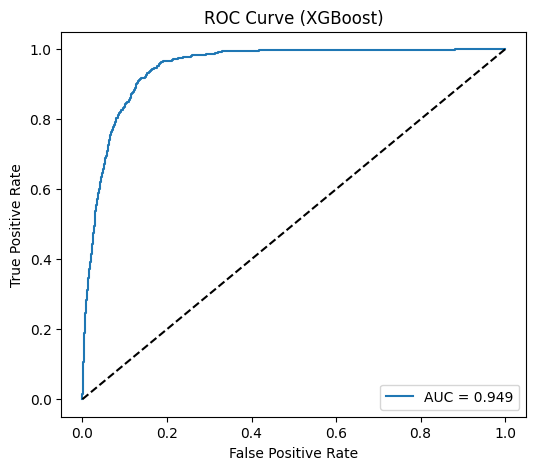

In [10]:
#ROC/AUC and plotting it
auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGBoost)')
plt.legend()
plt.show()

##using shap to find feature importance

In [11]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Calculating SHAP values for feature importance
sample_size = 2000  # Limiting sample size for computational efficiency
X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]

# Transform the sample using the preprocessor
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_sample)

# Convert sparse matrix to dense if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get feature names from the preprocessor
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Calculate SHAP values
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(best_model.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]  # For binary classification, class 1 (positive class)
else:
    shap_values_class1 = shap_values

# Debugging: check shapes
print(f"Shape of shap_values_class1: {shap_values_class1.shape}")
print(f"Shape of X_test_transformed: {X_test_transformed.shape}")
print(f"Number of features: {len(feature_names)}")

# Ensure 2D shape
if len(shap_values_class1.shape) == 3:
    # If it's 3D, take the values for class 1
    shap_values_class1 = shap_values_class1[:, :, 1]
    print(f"Converted to 2D shape: {shap_values_class1.shape}")

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)

print(f"\nShape of mean_abs_shap: {mean_abs_shap.shape}")
print(f"Length of feature_names: {len(feature_names)}")

# Create DataFrame for feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

# Display top N features
top_n = 20
top_features = feature_importance.head(top_n)

print(f"\nTop {top_n} most important features:")
print("="*70)
for i, row in enumerate(top_features.itertuples(), 1):
    print(f"{i:>2}. {row.feature:<45} {row.importance:.6f}")



/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP values...
Shape of shap_values_class1: (2000, 63)
Shape of X_test_transformed: (2000, 63)
Number of features: 63

Shape of mean_abs_shap: (63,)
Length of feature_names: 63

Top 20 most important features:
 1. num__duration                                 2.062863
 2. num__emp.var.rate                             0.798499
 3. num__nr.employed                              0.421030
 4. num__euribor3m                                0.250892
 5. num__cons.conf.idx                            0.198357
 6. num__age                                      0.106805
 7. num__pdays                                    0.081041
 8. cat__contact_cellular                         0.066658
 9. cat__month_may                                0.063620
10. num__cons.price.idx                           0.063542
11. num__campaign                                 0.060611
12. cat__default_no                               0.059469
13. cat__poutcome_failure                         0.058317
14. cat__da


✅ Saved: XGBoost_feature_importance_top20.png


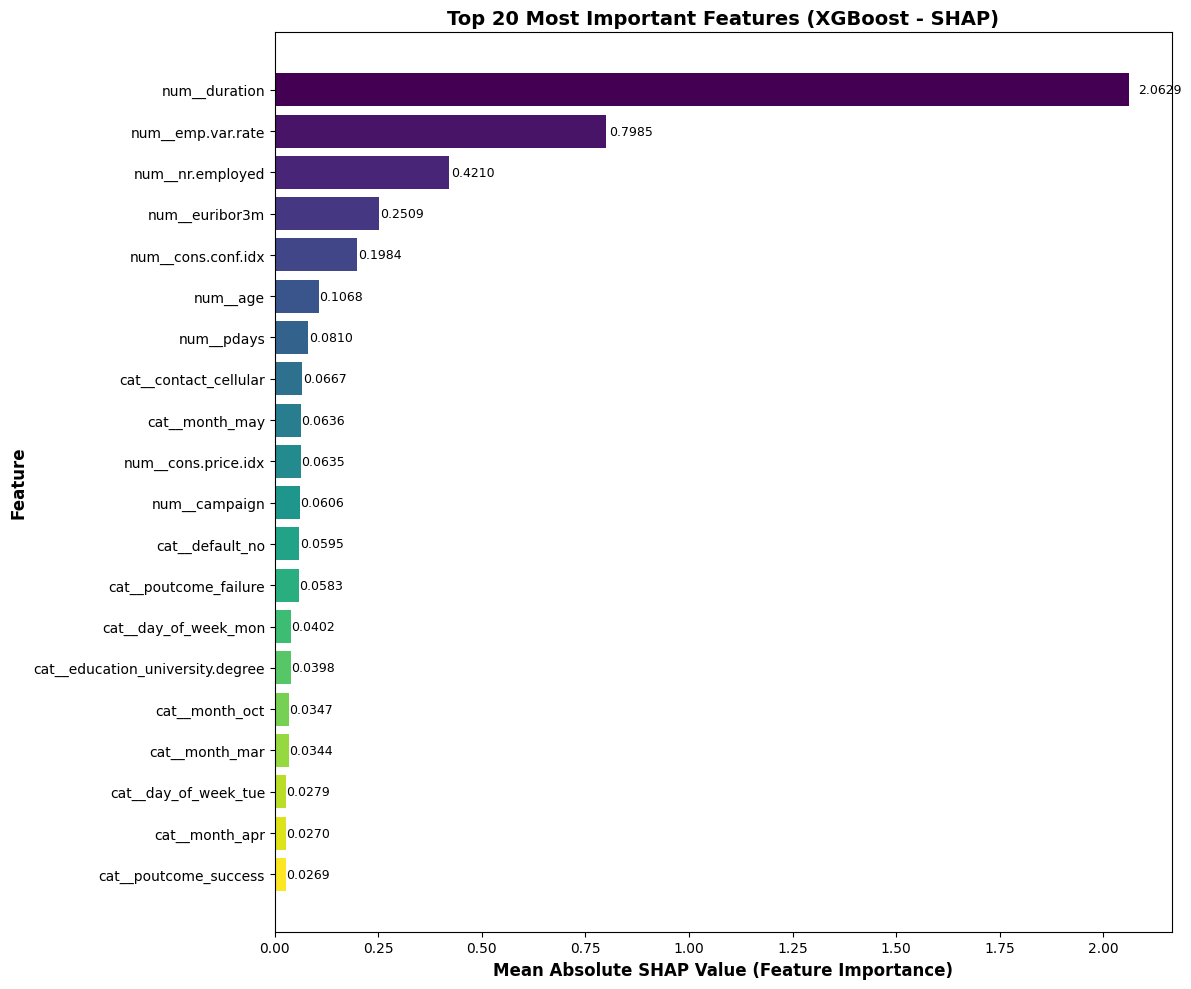

✅ Saved: XGBoost_all_feature_importance.csv (all 63 features)

SUMMARY
Total features analyzed: 63
Most important feature: num__duration
Importance range: 0.000000 to 2.062863

In top 20:
  Categorical features: 11
  Numerical features: 9


In [12]:
# Plot bar chart of top features
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=10)
plt.xlabel('Mean Absolute SHAP Value (Feature Importance)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features (XGBoost - SHAP)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels to bars
for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    plt.text(val + val*0.01, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'output/XGBoost_feature_importance_top{top_n}.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: XGBoost_feature_importance_top{top_n}.png")
plt.show()

# Save all feature importances to CSV
feature_importance.to_csv('output/XGBoost_all_feature_importance.csv', index=False)
print(f"✅ Saved: XGBoost_all_feature_importance.csv (all {len(feature_importance)} features)")

# Print summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Total features analyzed: {len(feature_names)}")
print(f"Most important feature: {top_features.iloc[0]['feature']}")
print(f"Importance range: {feature_importance['importance'].min():.6f} to {feature_importance['importance'].max():.6f}")

# Show categorical vs numerical breakdown
categorical_count = sum(1 for f in top_features['feature'] if 'cat__' in f)
numerical_count = sum(1 for f in top_features['feature'] if 'num__' in f)
print(f"\nIn top {top_n}:")
print(f"  Categorical features: {categorical_count}")
print(f"  Numerical features: {numerical_count}")